# One-dimensional Backwards Modeling
Before reading this tutorial, familiarize yourself with the forward modeling tutorial, which describes the coordinate system as well as the forward modeling classes.

In this tutorial, we discuss the 1D backwards problem: how to extract a 1D current distributions given only the SQUID signal? For this purpose, we work on a geometry that we understand well, by using the code of the forward modeling tutorial to generate a SQUID signal belonging to two edge currents.

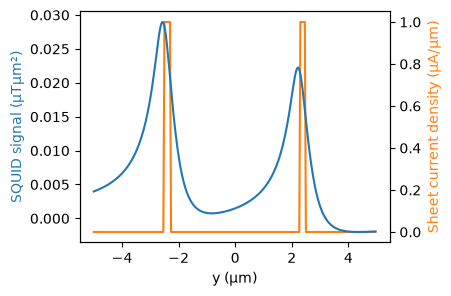

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sottools.forward as forward

params = forward.Forward1DParameters(
    Lscan = 10.0, # Scan length in microns
    Wdevice = 5.0, # Device (strip) width
    Nscan = 256, # Number of points in the SQUID scan
    gamma = 0.0,
    rho1 = 0.2,
    rho2 = 0.4,
    height = 0.5,
    phi = np.deg2rad(63.0), # Standard TM-SOT sensor tilt angle
    invert_normal=True # Sets the sign of the SQUID response
)

fwd = forward.Forward1D(params)

channelwidth = 0.2 # Width of the edge channels
ydevice = params.ydevice.cpu().numpy() # Convert to NumPy from Torch
yscan = params.yscan.cpu().numpy() # Convert to NumPy from Torch
currents = np.zeros_like(ydevice)
currents[(ydevice < -params.Wdevice/2 + channelwidth) | (ydevice > params.Wdevice/2 - channelwidth)] = 1.0

signal = fwd.forward(currents)

# For plotting esthetics, we embed currents in a zero-padded array of length Lscan
currents_plotting = np.zeros_like(yscan)
Nscan = len(yscan)
Ndevice = len(ydevice)
currents_plotting[Nscan//2-Ndevice//2:Nscan//2+Ndevice//2] = currents

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax_current = ax.twinx()
ax_current.plot(yscan, currents_plotting, color='C1')
ax.plot(yscan, signal, color='C0')
ax.set_zorder(ax_current.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_xlabel('y (µm)')
ax.set_ylabel('SQUID signal (µTµm²)', color='C0')
ax_current.set_ylabel('Sheet current density (µA/µm)', color='C1')
plt.show()

Now we have a SQUID signal that we can use to test the backwards modeling. In SOTtools, backwards modeling is geometry-aware. That is, we must provide a Forward1D object that represents the full forward calculation pipeline, both SQUID and sample, even if working on real experimental data. The obvious advantage of this is that results are much more likely to be physically meaningful, as the backwards modeling is constrained by the geometry of the problem.

Just like forward problems are run by objects, inversion is also run by objects. The Backward1D class is initialized with a Forward1D object, and then can be used to perform the inversion of any SQUID signal.

In [5]:
import sottools.backward as backward

inverter = backward.Inverter1D(fwd, signal)

Inversion is now as simple as calling the fit() function and waiting for the loss to converge. To keep the inversion process visual, we use a JupyterCallback object to plot the fit result as the fit progresses.

In [11]:
cb = backward.JupyterCallback()
ydevice_fitted, currents_fitted, _ = inverter.fit(
    lr = 1e-2, # Learning rate
    n_steps = 5000, # Number of steps
    callback = cb,
    callback_every = 500
)

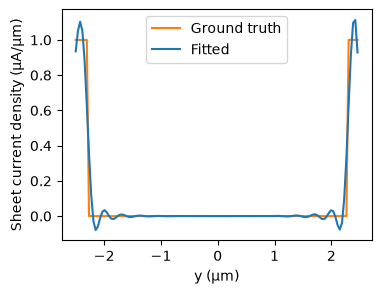

In [13]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(ydevice, currents, color='C1', label='Ground truth')
ax.plot(ydevice_fitted, currents_fitted, color='C0', label='Fitted')
ax.set_xlabel('y (µm)')
ax.set_ylabel('Sheet current density (µA/µm)')
ax.legend()
plt.show()

The fit is reasonable but has a lot of ringing. Such ringing near the edges is typical for inversion problems, and it is one of the reasons SOTtools incorporates regularization. 1D inversion supports four regularizers:

- lam1: 1st order TV regularization, promotes piecewise constant solutions
- lam2: 2nd order TV regularization, promotes piecewise linear solutions
- lam3: positivity regularization, promotes positive solutions
- lam4: near-edge positivity regularization, suppresses ringing within n_edge grid points of the edges of the device

Their weights lam1, lam2, lam3, lam4 can be passed on construction or modified later. In this case, we can fix the ringing using light TV-1 regularization.

In [24]:
inverter.lam1 = 1e-5
inverter.reset() # Reset the optimizer state
ydevice_fitted, currents_fitted, _ = inverter.fit(
    lr = 1e-2, # Learning rate
    n_steps = 5000, # Number of steps
    callback = cb,
    callback_every = 500
)

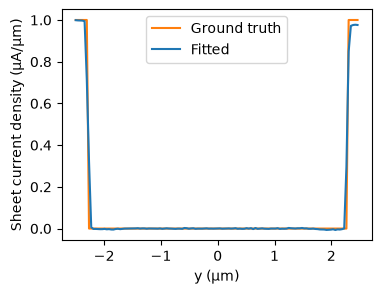

In [25]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(ydevice, currents, color='C1', label='Ground truth')
ax.plot(ydevice_fitted, currents_fitted, color='C0', label='Fitted')
ax.set_xlabel('y (µm)')
ax.set_ylabel('Sheet current density (µA/µm)')
ax.legend()
plt.show()

To illustrate this ringing is prevalent near the edges, we show that for a simple current consisting of two overlapping Gaussians in the center, inversion without regularization is able to recover the current distribution almost perfectly.

In [30]:
currents_two_gaussians = np.exp(-((ydevice+1.0)/0.5)**2) + np.exp(-((ydevice-1.0)/0.5)**2)
signal_two_gaussians = fwd.forward(currents_two_gaussians)

inverter_two_gaussians = backward.Inverter1D(fwd, signal_two_gaussians)
ydevice_fitted_two_gaussians, currents_fitted_two_gaussians, _ = inverter_two_gaussians.fit(
    lr=1e-2,  # Learning rate
    n_steps=5000,  # Number of steps
    callback=cb,
    callback_every=500
)


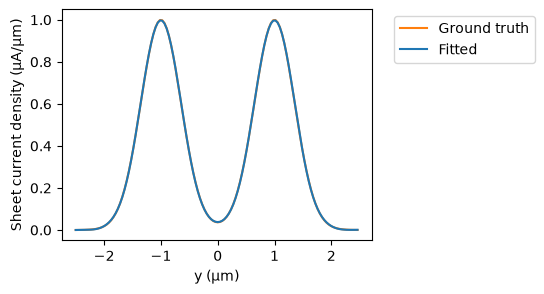

In [32]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(ydevice, currents_two_gaussians, color='C1', label='Ground truth')
ax.plot(ydevice_fitted_two_gaussians, currents_fitted_two_gaussians, color='C0', label='Fitted')
ax.set_xlabel('y (µm)')
ax.set_ylabel('Sheet current density (µA/µm)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

However, regularization is critical in the presence of noise. Above a certain noise level, inversion will become completely impossible if regularization is not used. We illustrate this here, for four SNR levels.

In [39]:
SNR = [10000, 100, 30, 10]

ground_truth = currents_fitted_two_gaussians
signal = fwd.forward(ground_truth)
noisy_signals = []
rng = np.random.default_rng(seed=42)  # For reproducibility

for snr in SNR:
    noise = rng.normal(0, np.max(signal)/snr, size=signal.shape)
    noisy_signals.append(signal + noise)

current_reconstructions_no_reg = []
current_reconstructions_regularized = []

for noisy_signal in noisy_signals:
    inverter_no_reg = backward.Inverter1D(fwd, noisy_signal)
    ydevice_fitted_no_reg, currents_fitted_no_reg, _ = inverter_no_reg.fit(
        lr=1e-2,  # Learning rate
        n_steps=5000,  # Number of steps
        callback=cb,
        callback_every=500
    )
    current_reconstructions_no_reg.append(currents_fitted_no_reg)

    inverter_regularized = backward.Inverter1D(fwd, noisy_signal)
    inverter_regularized.lam2 = 1e-3 # TV-2 is well-suited for reconstructing smooth distributions like Gaussians
    ydevice_fitted_reg, currents_fitted_reg, _ = inverter_regularized.fit(
        lr=1e-2,  # Learning rate
        n_steps=5000,  # Number of steps
        callback=cb,
        callback_every=500
    )
    current_reconstructions_regularized.append(currents_fitted_reg)

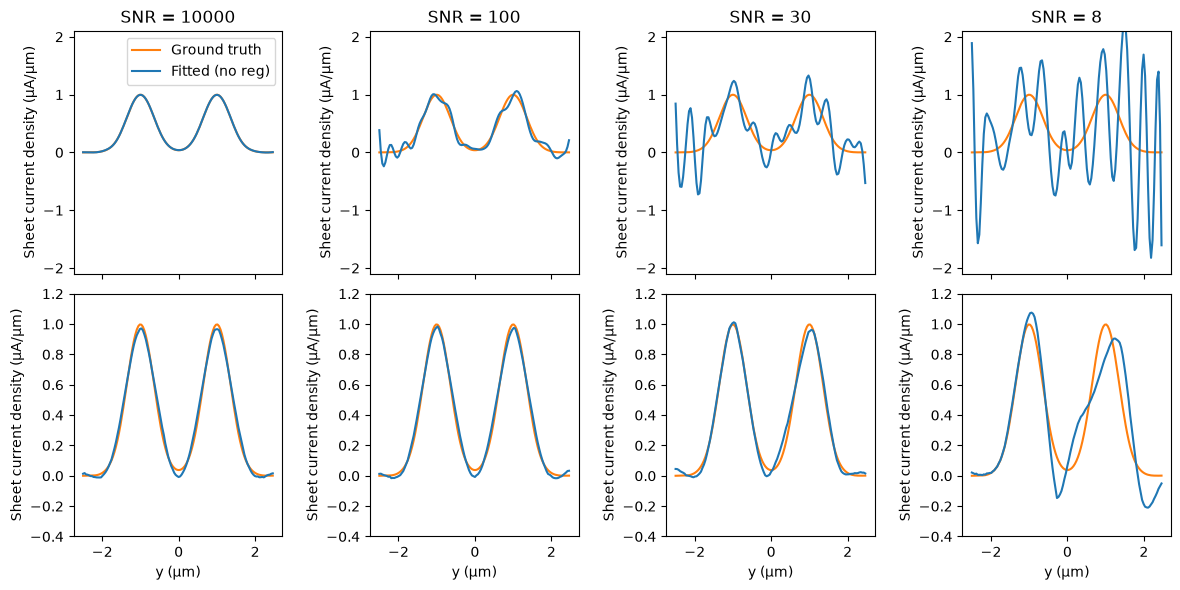

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
for i, snr in enumerate(SNR):
    axes[0, i].plot(ydevice, ground_truth, color='C1', label='Ground truth')
    axes[0, i].plot(ydevice, current_reconstructions_no_reg[i], color='C0', label='Fitted (no reg)')
    axes[1, i].plot(ydevice, ground_truth, color='C1', label='Ground truth')
    axes[1, i].plot(ydevice, current_reconstructions_regularized[i], color='C0', label='Fitted (reg)')
    axes[0, i].set_title(f'SNR = {snr}')
    axes[1, i].set_xlabel('y (µm)')
    axes[0, i].set_ylabel('Sheet current density (µA/µm)')
    axes[1, i].set_ylabel('Sheet current density (µA/µm)')
    axes[0, i].set_ylim(-2.1,2.1)
    axes[1, i].set_ylim(-0.4,1.2)

axes[0, 0].legend()
plt.tight_layout()
plt.show()